# Synthetic floor-control manuscript figure

This notebook is **visualization-only**.

The negative control keeps the frozen PBMC expression matrix, donor structure, and
HVG/PCA/Harmony/scVI representations unchanged, but replaces biological cell-type
labels with donor-balanced random pseudo-labels. Therefore there is no genuine
expression → label relationship.

Expected floor behavior:

- random cell-level macro-F1 ≈ chance,
- donor-held-out macro-F1 ≈ chance,
- random − donor macro-F1 ≈ 0.

The numerical experiment is produced by:

```bash
python scripts/run_synthetic_floor.py --clean-output
```


In [10]:
from pathlib import Path
import json
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

def find_repo_root(start=Path.cwd()):
    start = Path(start).resolve()
    for p in [start, *start.parents]:
        if (p / "src" / "scrna_benchmark").is_dir():
            return p
    raise RuntimeError("Run this notebook from inside the repository.")

REPO_ROOT = find_repo_root()
if str(REPO_ROOT / "src") not in sys.path:
    sys.path.insert(0, str(REPO_ROOT / "src"))

from scrna_benchmark.plotting import (
    DEFAULT_REP_LABELS,
    DEFAULT_REP_ORDER,
)

RESULT_DIR = REPO_ROOT / "results/synthetic_floor"
FIG_DIR = REPO_ROOT / "figures/synthetic_floor"
CACHE_DIR = REPO_ROOT / "results/figure_data"

FIG_DIR.mkdir(parents=True, exist_ok=True)
CACHE_DIR.mkdir(parents=True, exist_ok=True)

RUNS_PATH = RESULT_DIR / "null_control_runs.csv"
REPLICATES_PATH = RESULT_DIR / "null_control_replicates.csv"
DELTAS_PATH = RESULT_DIR / "null_control_deltas.csv"
BALANCE_PATH = RESULT_DIR / "null_label_balance.csv"
CONFIG_PATH = RESULT_DIR / "config.json"

required = [
    RUNS_PATH,
    REPLICATES_PATH,
    DELTAS_PATH,
    BALANCE_PATH,
    CONFIG_PATH,
]
missing = [p for p in required if not p.exists()]
if missing:
    raise FileNotFoundError(
        "Missing synthetic-floor outputs. Run "
        "`python scripts/run_synthetic_floor.py --clean-output` first. "
        f"Missing: {missing}"
    )

print(REPO_ROOT)


/users/xchen5/scRNA-cross-donor-generalization


## Load and audit the negative-control outputs

In [11]:
runs = pd.read_csv(RUNS_PATH)
replicates = pd.read_csv(REPLICATES_PATH)
deltas = pd.read_csv(DELTAS_PATH)
balance = pd.read_csv(BALANCE_PATH)

with open(CONFIG_PATH, "r", encoding="utf-8") as handle:
    config = json.load(handle)

display(pd.DataFrame([{
    "cells": config["n_cells"],
    "donors": config["n_donors"],
    "synthetic_classes": config["n_classes"],
    "label_randomizations": len(config["label_seeds"]),
    "random_splits_per_randomization": len(config["random_split_seeds"]),
    "donor_folds": config["n_folds"],
    "chance_macro_f1": config["chance_macro_f1"],
}]))

donor_col = config["donor_col"]
imbalance = (
    balance
    .groupby(["label_seed", donor_col])["n_cells"]
    .agg(lambda x: x.max() - x.min())
)

assert imbalance.max() <= 1
assert set(replicates["scheme"]) == {"random_split", "donor_cv"}
assert set(deltas["representation"]).issubset(set(DEFAULT_REP_ORDER))

print(
    "Maximum within-donor pseudo-class count difference:",
    int(imbalance.max()),
)
print("Donor-balanced label audit passed.")


,cells,donors,synthetic_classes,label_randomizations,random_splits_per_randomization,donor_folds,chance_macro_f1
0,10107,23,13,10,1,5,0.076923


Maximum within-donor pseudo-class count difference: 1
Donor-balanced label audit passed.


## Numerical summary

In [12]:
scheme_summary = (
    replicates
    .groupby(["representation", "scheme"], as_index=False)
    .agg(
        macro_f1_mean=("macro_f1_mean", "mean"),
        macro_f1_sd=("macro_f1_mean", "std"),
    )
)

delta_summary = (
    deltas
    .groupby("representation", as_index=False)
    .agg(
        delta_mean=("delta_macro_f1", "mean"),
        delta_sd=("delta_macro_f1", "std"),
    )
)

summary = scheme_summary.merge(
    delta_summary,
    on="representation",
    how="left",
)
summary["chance_macro_f1"] = config["chance_macro_f1"]
summary.to_csv(
    CACHE_DIR / "synthetic_floor_summary.csv",
    index=False,
)

display(summary)


,representation,scheme,macro_f1_mean,macro_f1_sd,delta_mean,delta_sd,chance_macro_f1
0,harmony,donor_cv,0.071183,0.002350,0.001719,0.004816,0.076923
1,harmony,random_split,0.072902,0.005842,0.001719,0.004816,0.076923
2,hvg,donor_cv,0.075486,0.001664,0.001101,0.005503,0.076923
3,hvg,random_split,0.076587,0.004971,0.001101,0.005503,0.076923
4,pca,donor_cv,0.070145,0.002786,0.002412,0.005746,0.076923
5,pca,random_split,0.072557,0.004793,0.002412,0.005746,0.076923
6,scvi,donor_cv,0.069069,0.003062,-0.000078,0.007516,0.076923
7,scvi,random_split,0.068990,0.007308,-0.000078,0.007516,0.076923


## Manuscript figure

**Panel A** shows absolute macro-F1 under the two evaluation schemes. The dashed
line is the theoretical balanced random-guess benchmark, \(1/K\).

**Panel B** shows the paired inflation quantity,
\(\Delta F_1 = F_{1,random} - F_{1,donor}\), for each independent synthetic-label
randomization. A floor control should be centered near zero.


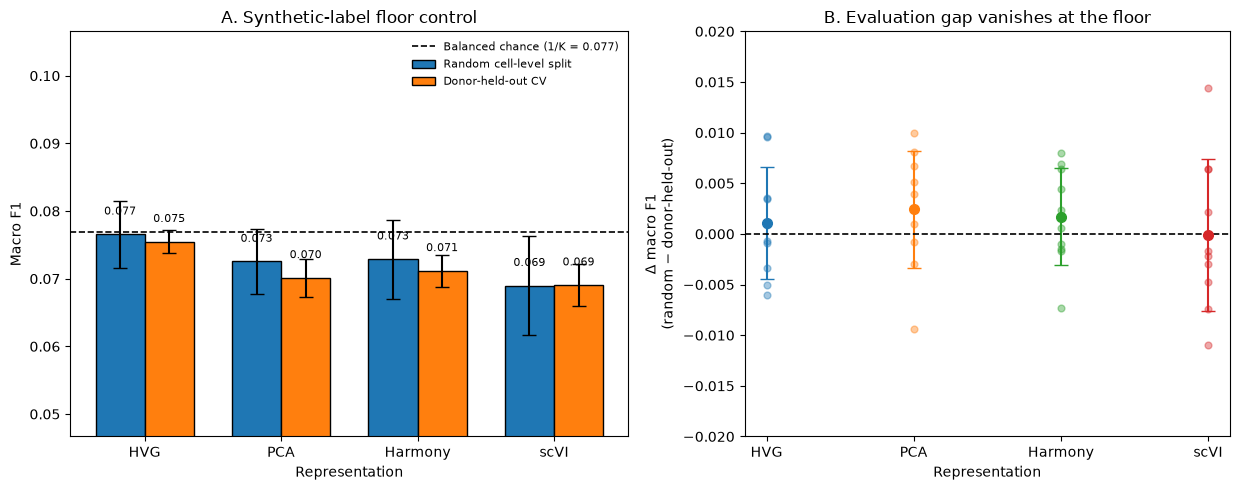

/users/xchen5/scRNA-cross-donor-generalization/figures/synthetic_floor/synthetic_floor_control.pdf


In [13]:
rep_order = [
    rep for rep in DEFAULT_REP_ORDER
    if rep in set(replicates["representation"])
]
rep_labels = [
    DEFAULT_REP_LABELS.get(rep, rep)
    for rep in rep_order
]

scheme_order = ["random_split", "donor_cv"]
scheme_labels = {
    "random_split": "Random cell-level split",
    "donor_cv": "Donor-held-out CV",
}

# ------------------------------------------------------------
# Summaries for Panel A
# ------------------------------------------------------------
summary = (
    replicates
    .groupby(
        ["representation", "scheme"],
        as_index=False,
    )["macro_f1_mean"]
    .agg(["mean", "std"])
    .reset_index()
    .rename(
        columns={
            "mean": "macro_f1_mean",
            "std": "macro_f1_std",
        }
    )
)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(12.5, 5),
    gridspec_kw={"width_ratios": [1.15, 1]},
)

x = np.arange(len(rep_order))
width = 0.36


# ============================================================
# Panel A: absolute macro-F1
# Same visual language as plot_random_vs_donor_cv()
# ============================================================
ax = axes[0]

random_summary = (
    summary.loc[
        summary["scheme"].eq("random_split")
    ]
    .set_index("representation")
    .reindex(rep_order)
)

donor_summary = (
    summary.loc[
        summary["scheme"].eq("donor_cv")
    ]
    .set_index("representation")
    .reindex(rep_order)
)

bars_random = ax.bar(
    x - width / 2,
    random_summary["macro_f1_mean"],
    width,
    yerr=random_summary["macro_f1_std"],
    capsize=5,
    label=scheme_labels["random_split"],
    edgecolor="black",
)

bars_donor = ax.bar(
    x + width / 2,
    donor_summary["macro_f1_mean"],
    width,
    yerr=donor_summary["macro_f1_std"],
    capsize=5,
    label=scheme_labels["donor_cv"],
    edgecolor="black",
)

chance = float(config["chance_macro_f1"])

ax.axhline(
    chance,
    linestyle="--",
    linewidth=1.2,
    color="black",
    label=f"Balanced chance (1/K = {chance:.3f})",
)

# Match the representation formatting used in the real datasets.
ax.set_xticks(x)
ax.set_xticklabels(rep_labels)
ax.set_xlabel("Representation")
ax.set_ylabel("Macro F1")
ax.set_title("A. Synthetic-label floor control")

# Annotate means exactly like the standard benchmark plots.
for bars in (bars_random, bars_donor):
    for bar in bars:
        h = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            h + 0.0025,
            f"{h:.3f}",
            ha="center",
            va="bottom",
            fontsize=8,
        )

# Keep the range focused on the floor rather than forcing 0–1.
all_low = np.concatenate([
    (
        random_summary["macro_f1_mean"]
        - random_summary["macro_f1_std"]
    ).to_numpy(),
    (
        donor_summary["macro_f1_mean"]
        - donor_summary["macro_f1_std"]
    ).to_numpy(),
    np.array([chance]),
])

all_high = np.concatenate([
    (
        random_summary["macro_f1_mean"]
        + random_summary["macro_f1_std"]
    ).to_numpy(),
    (
        donor_summary["macro_f1_mean"]
        + donor_summary["macro_f1_std"]
    ).to_numpy(),
    np.array([chance]),
])

ax.set_ylim(
    max(0, float(np.nanmin(all_low)) - 0.015),
    float(np.nanmax(all_high)) + 0.025,
)

ax.legend(
    frameon=False,
    fontsize=8,
)


# ============================================================
# Panel B: paired random − donor-held-out delta
# ============================================================
ax = axes[1]

for i, rep in enumerate(rep_order):
    vals = (
        deltas.loc[
            deltas["representation"].eq(rep),
            "delta_macro_f1",
        ]
        .dropna()
        .to_numpy()
    )

    # Show the individual random-label replicates lightly.
    ax.scatter(
        np.full(len(vals), x[i]),
        vals,
        s=24,
        alpha=0.40,
    )

    mean = vals.mean()
    sd = vals.std(ddof=1)

    ax.errorbar(
        x[i],
        mean,
        yerr=sd,
        fmt="o",
        capsize=5,
        markersize=7,
        linewidth=1.5,
    )

ax.axhline(
    0,
    linestyle="--",
    linewidth=1.2,
    color="black",
)

ax.set_xticks(x)
ax.set_xticklabels(rep_labels)
ax.set_xlabel("Representation")
ax.set_ylabel("Δ macro F1\n(random − donor-held-out)")
ax.set_title("B. Evaluation gap vanishes at the floor")

max_abs = max(
    0.02,
    float(
        np.nanmax(
            np.abs(deltas["delta_macro_f1"])
        )
    )
    + 0.005,
)

ax.set_ylim(
    -max_abs,
    max_abs,
)

fig.tight_layout()

pdf_path = FIG_DIR / "synthetic_floor_control.pdf"

fig.savefig(
    pdf_path,
    bbox_inches="tight",
)


plt.show()

print(pdf_path)

## Interpretation

This is a **negative control**, not a sixth biological cohort.

The expression data and donor structure are real, but the prediction target is
artificial and deliberately independent of expression. If the experiment behaves
as intended, both evaluation schemes should approach chance and their difference
should approach zero.

Together with the biological datasets, this supports a three-regime interpretation:

1. **floor:** no usable label signal → both schemes fail similarly;
2. **intermediate:** usable biological signal plus donor-specific structure →
   random cell-level splitting can be optimistic;
3. **ceiling:** the classification task is already very easy → both schemes
   perform similarly because little headroom remains.
